In [33]:
from nilearn import datasets, surface
from os import listdir
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import nibabel as nib
import nilearn.plotting as nplt
import pandas as pd

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'

subList = [f[4:] for f in listdir(op.join(bids_folder,'derivatives/encoding_model.smoothed')) if f[0:3] == 'sub']


In [9]:
def get_r2_data_from_surf(sub,bids_folder ='/Volumes/mrenkeED/data/ds-stressrisk',hemi='lh'):
    pati =  op.join(bids_folder, f'derivatives/encoding_model.smoothed/sub-{sub}/ses-1/func/') 
    file =  op.join(pati, f'sub-{sub}_ses-1_task-risk_space-fsnative_hemi-{hemi}_r2.surf.gii')
    return nib.load(file).agg_data()

def get_ips_mask_from_surf(sub,bids_folder ='/Volumes/mrenkeED/data/ds-stressrisk',hemi='lh'):
    pati =  op.join(bids_folder, f'derivatives/ips_masks/sub-{sub}/') 
    hemi_name = 'L' if hemi == 'lh' else 'R'
    file =  op.join(pati, f'sub-{sub}_desc-NPC_{hemi_name}_space-fsnative_hemi-{hemi}.ips.gii')
    return nib.load(file).agg_data()

In [95]:
df = pd.DataFrame(columns=['subject','N_ips_mask_L','N_ips_mask_R','mean_r2_ips_L','mean_r2_ips_R', 'mean_r2_L','mean_r2_R', 'N_07r2_ips_L','N_r2>.07_ips_R' ])

sub_erros = []
for sub in subList:
    try:
        r2_data_l= get_r2_data_from_surf(sub,hemi='lh')
        ips_l = get_ips_mask_from_surf(sub,hemi='lh')

        r2_data_r= get_r2_data_from_surf(sub,hemi='rh')
        ips_r = get_ips_mask_from_surf(sub,hemi='rh')
        
        N_ips_mask_l = len(ips_l[ips_l==1])
        mean_r2_ips_l = np.mean(r2_data_l[ips_l == 1])
        mean_r2_l = np.mean(r2_data_r)
        N_07r2_ips_l = len(r2_data_l[(ips_l == 1) & (r2_data_l > 0.07)])

        N_ips_mask_r = len(ips_r[ips_r==1])
        mean_r2_ips_r = np.mean(r2_data_r[ips_r == 1])
        mean_r2_r = np.mean(r2_data_r)
        N_07r2_ips_r = len(r2_data_r[(ips_r == 1) & (r2_data_r > 0.07)])


        df_subs = pd.DataFrame(data=[int(sub),int(N_ips_mask_l),int(N_ips_mask_r), 
                                     mean_r2_ips_l, mean_r2_ips_r, 
                                     mean_r2_l,mean_r2_r,
                                     int(N_07r2_ips_l), int(N_07r2_ips_r)]).T
        df_subs.columns = df.columns
        df = pd.concat([df, df_subs],axis=0)
        
    except:
        #print(sub)
        sub_erros.append(sub)

df['subject'] = df['subject'].astype(int)
df =df.set_index('subject')

df.head(n=2)

,N_ips_mask_L,N_ips_mask_R,mean_r2_ips_L,mean_r2_ips_R,mean_r2_L,mean_r2_R,N_07r2_ips_L,N_r2>.07_ips_R
subject,,,,,,,,
13,7732.0,9236.0,0.033359,0.037497,0.037662,0.037662,289.0,444.0
14,8139.0,9996.0,0.039410,0.032346,0.037412,0.037412,901.0,596.0


In [115]:
df = pd.DataFrame(columns=['subject','hemi','Nvertices_ipsMask','Nvertices_r2>.07_&ipsMask','mean_r2_ips','mean_r2_all',  ])

sub_erros = []
for sub in subList:
    try:
        r2_data_l= get_r2_data_from_surf(sub,hemi='lh')
        ips_l = get_ips_mask_from_surf(sub,hemi='lh')

        r2_data_r= get_r2_data_from_surf(sub,hemi='rh')
        ips_r = get_ips_mask_from_surf(sub,hemi='rh')
        
        N_ips_mask_l = len(ips_l[ips_l==1])
        mean_r2_ips_l = np.mean(r2_data_l[ips_l == 1])
        mean_r2_l = np.mean(r2_data_l)
        N_07r2_ips_l = len(r2_data_l[(ips_l == 1) & (r2_data_l > 0.07)])

        N_ips_mask_r = len(ips_r[ips_r==1])
        mean_r2_ips_r = np.mean(r2_data_r[ips_r == 1])
        mean_r2_r = np.mean(r2_data_r)
        N_07r2_ips_r = len(r2_data_r[(ips_r == 1) & (r2_data_r > 0.07)])


        df_L = pd.DataFrame(data=[int(sub),'L',
                                    N_ips_mask_l,
                                    N_07r2_ips_l,
                                    mean_r2_ips_l, 
                                    mean_r2_l]).T
        df_R = pd.DataFrame(data=[int(sub), 'R',
                                    N_ips_mask_r, 
                                    N_07r2_ips_r,
                                    mean_r2_ips_r, 
                                    mean_r2_r]).T
        df_L.columns = df.columns
        df_R.columns = df.columns

        df = pd.concat([df, df_L, df_R],axis=0)
        
    except:
        #print(sub)
        sub_erros.append(sub)

df['subject'] = df['subject'].astype(int)
df =df.set_index(['subject','hemi'])

df.head(n=2)

Nvertices_ipsMask Nvertices_r2>.07_&ipsMask mean_r2_ips  \
subject hemi                                                           
13      L                 7732                       289    0.033359   
        R                 9236                       444    0.037497   

             mean_r2_all  
subject hemi              
13      L       0.039836  
        R       0.037662

In [120]:
df['N_r2/ips'] = df['Nvertices_r2>.07_&ipsMask'] / df['Nvertices_ipsMask']

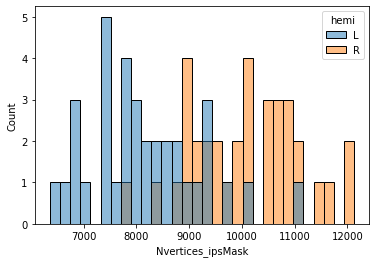

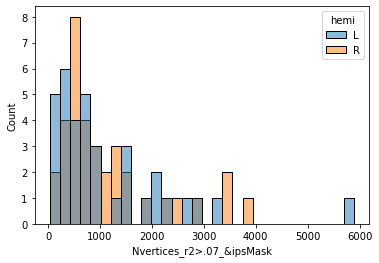

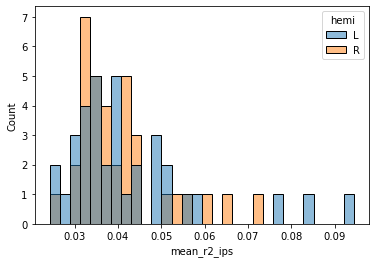

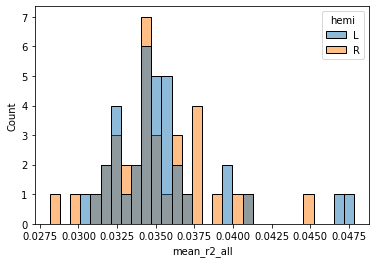

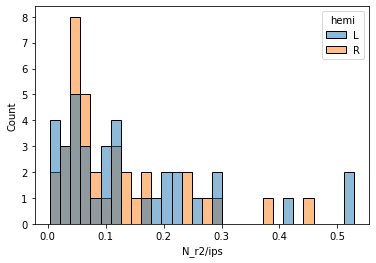

In [121]:
import seaborn as sns

for metric in df.columns:
    plt.figure()
    sns.histplot(df.reset_index(), x=metric, hue='hemi',bins=30)